
CLUSTER 0
                                 country
                                    year
                         reporting_level
                            welfare_type
                             ppp_version
                             survey_year
                    survey_comparability
   headcount_ratio_international_povline
headcount_ratio_lower_mid_income_povline
headcount_ratio_upper_mid_income_povline

CLUSTER 1
decile1_thr
decile2_thr
decile3_thr
decile4_thr
decile6_thr
decile7_thr
decile8_thr
decile9_thr

CLUSTER 2
 avg_shortfall_100
avg_shortfall_1000
avg_shortfall_2000
avg_shortfall_3000
avg_shortfall_4000

CLUSTER 3
 decile1_avg
 decile2_avg
 decile3_avg
 decile4_avg
 decile5_avg
 decile6_avg
 decile7_avg
 decile8_avg
 decile9_avg
decile10_avg

CLUSTER 4
 decile1_share
 decile2_share
 decile3_share
 decile4_share
 decile5_share
 decile6_share
 decile7_share
 decile8_share
 decile9_share
decile10_share


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4557/160599167.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


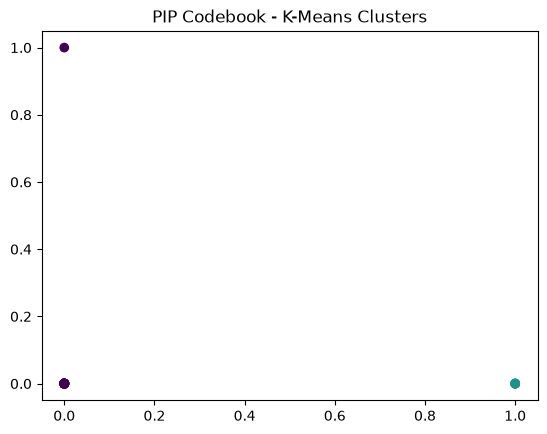

In [1]:
# Install if needed:
# !pip install pandas scikit-learn nltk matplotlib

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

nltk.download("stopwords")

# 1. Load dataset
df = pd.read_csv("pip_codebook.csv")

# 2. Select text column (change if needed)
text_col = df.select_dtypes(include="object").columns[0]
df[text_col] = df[text_col].fillna("").astype(str)

# 3. NLP cleaning
stop = set(stopwords.words("english"))

def clean(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text.lower())
    return " ".join(w for w in text.split() if w not in stop)

df["clean_text"] = df[text_col].apply(clean)

# 4. TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df["clean_text"])

# 5. K-Means
k = 5
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 6. Show clusters
for i in range(k):
    print(f"\nCLUSTER {i}")
    print(df[df["cluster"] == i][text_col].head(10).to_string(index=False))

# 7. Save result
df.to_csv("pip_codebook_clustered.csv", index=False)

# 8. Simple visualisation
plt.scatter(X[:, 0].toarray(), X[:, 1].toarray(), c=df["cluster"])
plt.title("PIP Codebook - K-Means Clusters")
plt.show()